# De corpus a hallazgos
## Text mining aplicado con Trafilatura, spaCy y representaciones sparse

**Duración estimada:** 70 minutos

---

## Propósito
Este cuaderno reúne en un solo recorrido varias operaciones que ya viste por separado: adquisición de textos, organización del corpus, procesamiento con spaCy, vectorización sparse y visualización analítica.

La meta no es producir un tablero espectacular ni automatizar la interpretación. La meta es construir **hallazgos iniciales** que te ayuden a pasar de una lectura distante a una lectura cercana mejor orientada.

## Marco de trabajo
- Tomamos de **Franco Moretti** la idea de que la lectura distante cambia la escala: permite mirar recurrencias, contrastes y series sin reemplazar la vuelta al fragmento.
- Mantenemos la **lectura cercana** como instancia de interpretación: después de detectar un patrón, volvemos al texto para ver cómo funciona en contexto.
- Para la visualización adoptamos un criterio de reducción y claridad inspirado en **John Maeda** y **Hans Rosling**: pocos gráficos, comparaciones legibles, color con jerarquía y anotaciones directas cuando ayudan a comprender.

## Resultados de aprendizaje
Al final deberías poder:
- adquirir un mini corpus real con `trafilatura`;
- normalizarlo en una tabla simple y reusable;
- construir observables con spaCy, frecuencias, bigramas y TF-IDF;
- usar visualizaciones sobrias para detectar patrones;
- volver del patrón al fragmento para sostener una lectura interpretativa.

---

## Corpus de trabajo

Vamos a usar tres textos de Valentín Muro publicados en Cenital. Comparten autor, medio y zona temática, pero desarrollan preguntas distintas sobre IA, lectura, ciencia y cognición. Eso vuelve al corpus pequeño, comparable e interpretable.

In [1]:
# --- Importaciones ---
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import trafilatura

# Configuración visual: estilo limpio y paleta accesible
sns.set_theme(style="ticks", context="notebook", palette="colorblind", font_scale=1.0)
PALETA = sns.color_palette("colorblind")
pd.set_option("display.max_colwidth", 140)

In [2]:
# --- Definición de fuentes ---
# Cada entrada tiene metadatos + un texto_demo de respaldo
# por si la descarga de la web falla.
FUENTES = [
    {
        "id": "muro_ia_cancer",
        "fecha": "2026-03-19",
        "medio": "Cenital",
        "autor": "Valentín Muro",
        "titulo": "No, ChatGPT no hizo una vacuna contra el cáncer",
        "url": "https://cenital.com/no-chatgpt-no-hizo-una-vacuna-contra-el-cancer/",
        "texto_demo": "El texto cuestiona la exageración tecnosolucionista alrededor de la IA en biomedicina. Sostiene que los chatbots pueden asistir la búsqueda y la organización de información, pero no reemplazan la validación experimental, la infraestructura científica ni el trabajo de laboratorio.",
    },
    {
        "id": "muro_resumenes",
        "fecha": "2026-03-05",
        "medio": "Cenital",
        "autor": "Valentín Muro",
        "titulo": "Te lo resumo así nomás: cuando la IA no ayuda",
        "url": "https://cenital.com/te-lo-resumo-asi-nomas-cuando-la-ia-no-ayuda/",
        "texto_demo": "El texto discute cómo los resúmenes automáticos prometen eficiencia a costa de reducir la fricción cognitiva. La crítica no se limita a los errores fácticos: también apunta al riesgo de delegar el esfuerzo de leer, dudar y construir comprensión propia.",
    },
    {
        "id": "muro_cerebro",
        "fecha": "2025-12-11",
        "medio": "Cenital",
        "autor": "Valentín Muro",
        "titulo": "El cerebro tal vez no sea una computadora",
        "url": "https://cenital.com/el-cerebro-tal-vez-no-sea-una-computadora/",
        "texto_demo": "El texto revisa la analogía entre cerebro y computadora. Reconoce su productividad histórica, pero marca sus límites para pensar la cognición, la biología y la materialidad del cerebro como un sistema evolutivo, continuo y encarnado.",
    },
]

# --- Parámetros globales ---
USAR_CORPUS_DEMO_SI_FALLA = True  # Si no se puede descargar, usar texto de respaldo
MODELO_SPACY = "es_core_news_sm"
TOP_N = 8                         # Cuántos términos mostrar en las tablas
VENTANA_FRAGMENTO = 140           # Caracteres alrededor del término para lectura cercana

---

## 1. Adquisición mínima con Trafilatura

Como ya viste la adquisición web en `002_Adquisicion_Corpus`, acá la usamos de forma instrumental: lo suficiente para obtener el texto, conservar metadatos básicos y pasar rápido al análisis.

Fijate que la función `extraer_texto()` se encarga de descargar y limpiar el HTML. Si falla, el cuaderno usa un texto de demostración para que el flujo no se corte.

In [3]:
def extraer_texto(url):
    """Descarga una URL y extrae el texto principal usando Trafilatura."""
    descargado = trafilatura.fetch_url(url)
    if not descargado:
        return None
    return trafilatura.extract(
        descargado,
        include_comments=False,
        include_tables=False,
        favor_precision=True,
    )

# Recorremos cada fuente e intentamos descargar el texto
registros = []
for fuente in FUENTES:
    texto = extraer_texto(fuente["url"])
    origen = "web"

    # Si la descarga falló, usamos el texto de demostración
    if not texto and USAR_CORPUS_DEMO_SI_FALLA:
        texto = fuente["texto_demo"]
        origen = "demo"

    registros.append({
        "id": fuente["id"],
        "fecha": fuente["fecha"],
        "medio": fuente["medio"],
        "autor": fuente["autor"],
        "titulo": fuente["titulo"],
        "url": fuente["url"],
        "texto": texto,
        "origen_texto": origen,
    })

# Armamos el DataFrame y limpiamos filas vacías
df = pd.DataFrame(registros)
df = df[df["texto"].fillna("").str.strip().ne("")].reset_index(drop=True)
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df["titulo_corto"] = [f"Texto {i + 1}" for i in range(len(df))]

# Contamos palabras aproximadas con un patrón que captura
# secuencias de 2+ letras (sin dígitos ni símbolos)
df["num_palabras"] = df["texto"].str.findall(r"\b[^\W\d_]{2,}\b").str.len()

print(f"Documentos disponibles: {len(df)}")
display(df[["id", "fecha", "medio", "autor", "titulo", "origen_texto", "num_palabras"]])

Documentos disponibles: 3


,id,fecha,medio,autor,titulo,origen_texto,num_palabras
0,muro_ia_cancer,2026-03-19,Cenital,Valentín Muro,"No, ChatGPT no hizo una vacuna contra el cáncer",web,1646
1,muro_resumenes,2026-03-05,Cenital,Valentín Muro,Te lo resumo así nomás: cuando la IA no ayuda,web,1649
2,muro_cerebro,2025-12-11,Cenital,Valentín Muro,El cerebro tal vez no sea una computadora,web,1560


---

## 2. Exploración inicial del corpus

Antes de modelizar, conviene mirar el recorte como conjunto de textos situados. En un corpus chico esto significa observar longitudes, fechas y equilibrio general del material.

In [4]:
# Armamos una tabla resumen con métricas básicas del corpus
resumen = pd.DataFrame({
    "métrica": [
        "documentos",
        "palabras aproximadas",
        "promedio por texto",
        "medio",
        "autor",
    ],
    "valor": [
        len(df),
        int(df["num_palabras"].sum()),
        round(df["num_palabras"].mean(), 1),
        df["medio"].iloc[0] if not df.empty else "sin dato",
        df["autor"].iloc[0] if not df.empty else "sin dato",
    ],
})

display(resumen)

,métrica,valor
0,documentos,3
1,palabras aproximadas,4855
2,promedio por texto,1618.3
3,medio,Cenital
4,autor,Valentín Muro


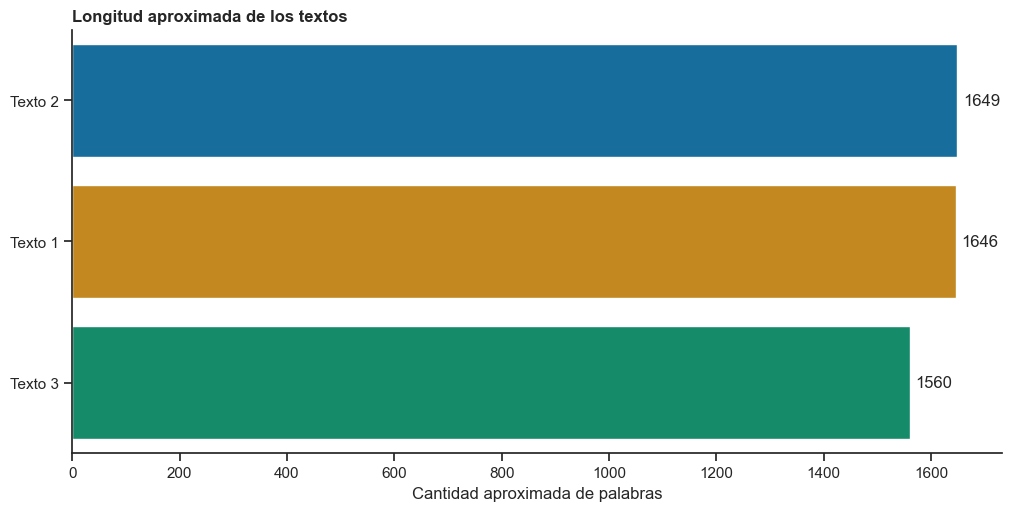

In [5]:
# Gráfico de longitud de los textos (barras horizontales)
df_longitudes = df.sort_values("num_palabras", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(
    data=df_longitudes,
    x="num_palabras",
    y="titulo_corto",
    hue="titulo_corto",
    palette="colorblind",
    legend=False,
    ax=ax,
)
# Etiquetas numéricas al final de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4)
ax.set_title("Longitud aproximada de los textos", loc="left", fontweight="bold")
ax.set_xlabel("Cantidad aproximada de palabras")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()

---

## 3. Procesamiento lingüístico con spaCy

Usamos spaCy para construir una primera capa de observables: lemas, palabras de contenido y entidades nombradas. Si el modelo no está disponible, el cuaderno activa un respaldo mínimo para no cortar el flujo de trabajo.

### ¿Qué hace cada parte?
- **Lematización:** reduce cada palabra a su forma base ("comieron" → "comer").
- **Filtrado de contenido:** descarta stopwords y signos, dejando solo palabras significativas.
- **Entidades nombradas:** detecta personas, organizaciones y lugares mencionados.

In [6]:
# Intentamos cargar spaCy; si falla, usamos un respaldo con regex
try:
    import spacy
    nlp = spacy.load(MODELO_SPACY)
    MODO_PREPROCESAMIENTO = "spacy"
    print(f"Modelo cargado correctamente: {MODELO_SPACY}")
except Exception as error:
    spacy = None
    nlp = None
    MODO_PREPROCESAMIENTO = "fallback_regex"
    print("No se pudo cargar spaCy. Se activa un respaldo mínimo.")
    print(f"Detalle técnico: {error}")

Modelo cargado correctamente: es_core_news_sm


In [7]:
# --- Patrón regex para el fallback ---
# Captura secuencias de 2+ letras Unicode (sin dígitos ni guiones bajos)
PATRON_PALABRAS = re.compile(r"\b[^\W\d_]{2,}\b", flags=re.UNICODE)

# Lista artesanal de stopwords para el caso sin spaCy
STOPWORDS_FALLBACK = {
    "de", "la", "el", "y", "en", "que", "a", "los", "las", "un", "una", "del", "por", "para",
    "con", "como", "se", "no", "al", "lo", "su", "sus", "es", "son", "si", "ya", "pero", "más",
    "entre", "desde", "también", "esta", "este", "sobre", "ni", "mi", "tu",
}


def normalizar_lemma(token):
    """Obtiene el lema limpio de un token spaCy."""
    lema = token.lemma_.strip().lower()
    # Si el lema es vacío o el pronombre genérico, usamos la forma original
    if not lema or lema == "-pron-":
        lema = token.text.lower()
    return lema


def procesar_con_spacy(textos):
    """Procesa una lista de textos con spaCy.
    Devuelve un DataFrame con: texto_lemas, texto_contenido, entidades."""
    resultados = []
    for doc in nlp.pipe(textos, batch_size=8):
        lemas = []
        contenido = []
        entidades = []

        for token in doc:
            if token.is_space:
                continue
            lema = normalizar_lemma(token)
            lemas.append(lema)
            # Solo palabras alfabéticas que no sean stopwords
            if token.is_alpha and not token.is_stop:
                contenido.append(lema)

        for entidad in doc.ents:
            entidades.append({"texto": entidad.text, "etiqueta": entidad.label_})

        resultados.append({
            "texto_lemas": " ".join(lemas),
            "texto_contenido": " ".join(contenido),
            "entidades": entidades,
        })
    return pd.DataFrame(resultados)


def procesar_sin_spacy(textos):
    """Procesamiento de respaldo: tokeniza con regex y filtra stopwords."""
    resultados = []
    for texto in textos:
        tokens = [t.lower() for t in PATRON_PALABRAS.findall(str(texto))]
        contenido = [t for t in tokens if t not in STOPWORDS_FALLBACK]
        resultados.append({
            "texto_lemas": " ".join(tokens),
            "texto_contenido": " ".join(contenido),
            "entidades": [],
        })
    return pd.DataFrame(resultados)


# --- Ejecutamos el procesamiento según el modo disponible ---
if MODO_PREPROCESAMIENTO == "spacy":
    df_linguistico = procesar_con_spacy(df["texto"].tolist())
else:
    df_linguistico = procesar_sin_spacy(df["texto"].tolist())

# Unimos los resultados al DataFrame principal
df = pd.concat([df.reset_index(drop=True), df_linguistico], axis=1)

# Elegimos el texto base para el modelo: contenido si lo hay, sino lemas
df["texto_modelo_base"] = df["texto_contenido"].where(
    df["texto_contenido"].str.strip().ne(""),
    df["texto_lemas"]
)

# Resumen legible de entidades
df["entidades_resumen"] = df["entidades"].apply(
    lambda lista: ", ".join(
        f"{item['texto']} [{item['etiqueta']}]" for item in lista
    ) if lista else "Sin entidades detectadas"
)

display(df[["titulo_corto", "texto_contenido", "entidades_resumen"]])

,titulo_corto,texto_contenido,entidades_resumen
0,Texto 1,simple mortal chatgpt escribir correo resumir fiaca leer emprendedor tecnológico australiano usar curar cáncer perro historia circular r...,"ChatGPT [MISC], Greg Brockman [PER], OpenAI [MISC], Sam Altman [PER], Silicon Valley [LOC], Fascinante [PER], The Australian [PER], Paul..."
1,Texto 2,famoso episodio seinfeld george anotar club lectura pensar él leer breakfast at librito doscientos página pasar jerry preguntar george b...,"Seinfeld [MISC], George [PER], Solo debe leer [MISC], Breakfast at Tiffany’s [MISC], Jerry [PER], George [PER], ¿verdad? [MISC], Jerry [..."
2,Texto 3,analogía máquina actividad neuronal convencer confesar psicólogo conductual karl lashley american neurological association junio basar s...,"Karl Lashley [PER], American Neurological Association [ORG], Descartes [PER], De allí tomó la inspiración [MISC], Mesmer [MISC], Galvani..."


---

## 4. Lectura distante: frecuencias, entidades y asociaciones

En el sentido operativo que nos interesa acá, la lectura distante no reemplaza la interpretación. Sirve para detectar regularidades, insistencias y contrastes que después conviene revisar en los textos mismos.

### 4.1 Términos más frecuentes del corpus

In [8]:
# Contamos los términos de contenido en todo el corpus
contador_terminos = Counter(" ".join(df["texto_modelo_base"]).split())
top_terminos = pd.DataFrame(
    contador_terminos.most_common(TOP_N),
    columns=["término", "frecuencia"]
)

display(top_terminos)

,término,frecuencia
0,él,35
1,cerebro,23
2,resumen,16
3,computadora,16
4,humano,15
5,dato,12
6,metáfora,12
7,leer,11


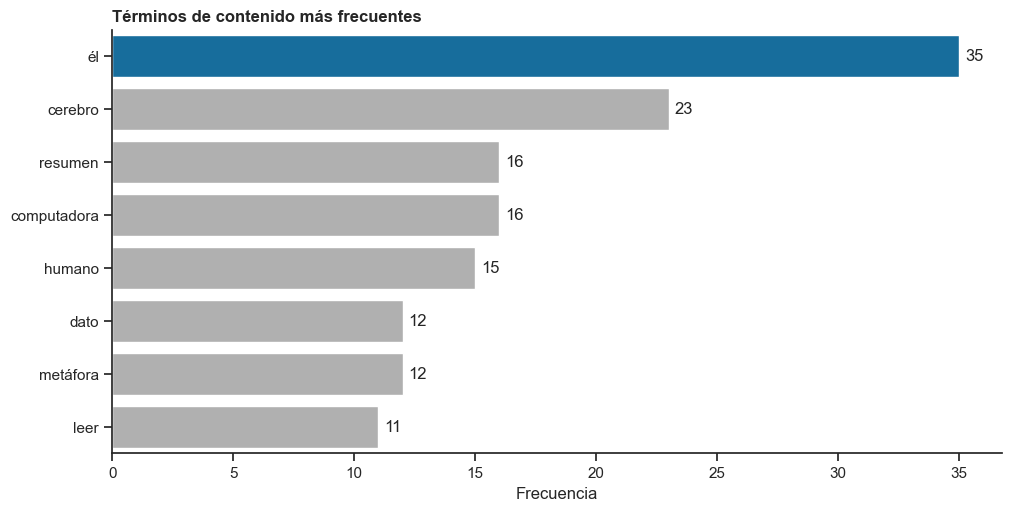

In [9]:
# Gráfico de barras: el primer término se destaca, el resto en gris
if not top_terminos.empty:
    colores = ["#b0b0b0"] * len(top_terminos)
    colores[0] = PALETA[0]  # El más frecuente en color

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    sns.barplot(
        data=top_terminos, x="frecuencia", y="término",
        hue="término", palette=colores, legend=False, ax=ax,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=4)
    ax.set_title("Términos de contenido más frecuentes", loc="left", fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")
    sns.despine(ax=ax)
    plt.show()

### 4.2 Entidades nombradas más frecuentes

Las entidades nombradas (personas, organizaciones, lugares) que spaCy detectó nos ayudan a ver quiénes y qué aparecen en el corpus.

In [10]:
# Desagregamos las entidades documento por documento
registros_entidades = []
for fila in df.itertuples(index=False):
    for entidad in fila.entidades:
        registros_entidades.append({
            "documento": fila.titulo_corto,
            "texto_entidad": entidad["texto"],
            "etiqueta": entidad["etiqueta"],
        })

df_entidades = pd.DataFrame(registros_entidades)

if not df_entidades.empty:
    # Agrupamos por texto+etiqueta, contamos y mostramos las más frecuentes
    top_entidades = (
        df_entidades
        .groupby(["texto_entidad", "etiqueta"])
        .size()
        .reset_index(name="frecuencia")
        .sort_values("frecuencia", ascending=False)
        .head(TOP_N)
    )
    display(top_entidades)
else:
    print("No se detectaron entidades suficientes para armar una tabla de trabajo.")

,texto_entidad,etiqueta,frecuencia
12,ChatGPT,MISC,5
119,Rosie,PER,5
49,Google,ORG,4
16,Conyngham,PER,4
8,Ayudalo,PER,3
2,Acá,PER,3
155,¿Cenital,ORG,3
108,Pero producir cuesta plata,MISC,3


### 4.3 Bigramas frecuentes

Los bigramas (pares de palabras consecutivas) ayudan a detectar asociaciones que los términos sueltos no capturan. Mirá si aparecen conceptos compuestos como "inteligencia artificial" o "lectura cercana".

,bigrama,frecuencia
1181,inteligencia artificial,8
293,cerebro computadora,6
580,dato confiable,4
283,cenital servir,3
175,audiencia tomar,3
756,entender periodismo,3
1026,gustar sumate,3
194,ayudalo seguir,3


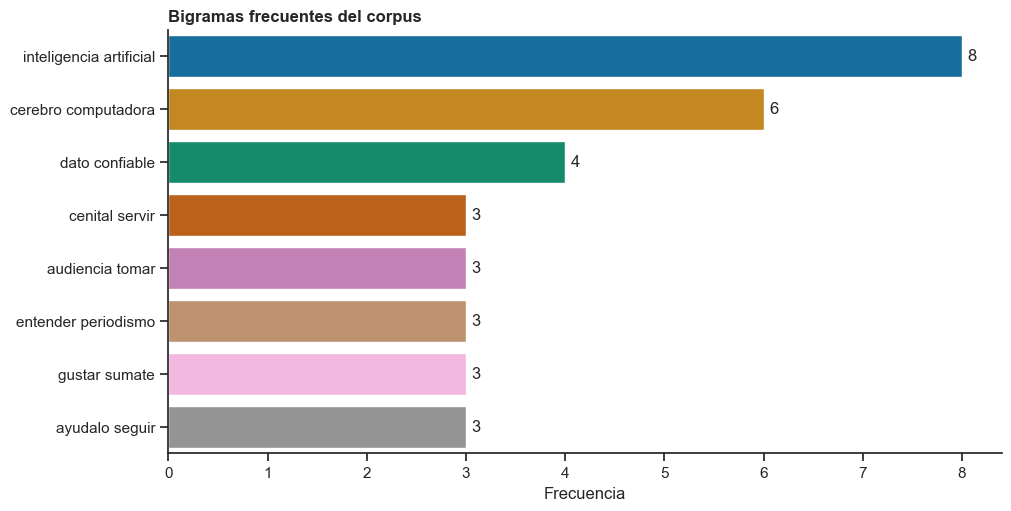

In [11]:
# Vectorizamos con bigramas (ngram_range=(2,2)) sobre el texto de contenido
vectorizador_bigramas = CountVectorizer(lowercase=False, ngram_range=(2, 2), min_df=1)
matriz_bigramas = vectorizador_bigramas.fit_transform(df["texto_modelo_base"])

# Sumamos frecuencias globales y mostramos los más repetidos
frecuencias_bigramas = pd.DataFrame({
    "bigrama": vectorizador_bigramas.get_feature_names_out(),
    "frecuencia": matriz_bigramas.sum(axis=0).A1,
}).sort_values("frecuencia", ascending=False).head(TOP_N)

display(frecuencias_bigramas)

# Gráfico de bigramas
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
sns.barplot(
    data=frecuencias_bigramas, x="frecuencia", y="bigrama",
    hue="bigrama", palette="colorblind", legend=False, ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4)
ax.set_title("Bigramas frecuentes del corpus", loc="left", fontweight="bold")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
sns.despine(ax=ax)
plt.show()

---

## 5. Bag of Words y TF-IDF por documento

Con este corpus pequeño conviene usar cada texto como unidad de análisis. Así podés ver qué términos aparecen en todos y cuáles vuelven singular a cada pieza.

Recordá del cuaderno anterior:
- **BoW** cuenta cuántas veces aparece cada palabra → volumen puro.
- **TF-IDF** pondera: le da más peso a las palabras que son frecuentes en *ese* documento pero raras en el resto → **distintividad**.

In [12]:
# Preparamos las unidades de análisis con sus textos procesados
unidades = df[["titulo_corto", "titulo", "texto_modelo_base"]].rename(
    columns={"titulo_corto": "unidad", "texto_modelo_base": "texto_modelo"}
)
display(unidades)

,unidad,titulo,texto_modelo
0,Texto 1,"No, ChatGPT no hizo una vacuna contra el cáncer",simple mortal chatgpt escribir correo resumir fiaca leer emprendedor tecnológico australiano usar curar cáncer perro historia circular r...
1,Texto 2,Te lo resumo así nomás: cuando la IA no ayuda,famoso episodio seinfeld george anotar club lectura pensar él leer breakfast at librito doscientos página pasar jerry preguntar george b...
2,Texto 3,El cerebro tal vez no sea una computadora,analogía máquina actividad neuronal convencer confesar psicólogo conductual karl lashley american neurological association junio basar s...


In [13]:
# --- Funciones auxiliares para BoW y TF-IDF ---

def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    """Convierte una matriz sparse en DataFrame legible."""
    return pd.DataFrame(matriz.toarray(), columns=nombres_columnas, index=nombres_filas)


def extraer_top_por_unidad(dataframe_matriz, top_n=5, nombre_valor="valor"):
    """Para cada unidad (fila), extrae los top_n términos con mayor valor."""
    resultados = []
    for unidad, serie in dataframe_matriz.iterrows():
        # Filtramos valores > 0, ordenamos de mayor a menor
        top = serie[serie > 0].sort_values(ascending=False).head(top_n)
        for rango, (termino, valor) in enumerate(top.items(), start=1):
            resultados.append({
                "unidad": unidad,
                "rango": rango,
                "término": termino,
                nombre_valor: round(float(valor), 4),
            })
    return pd.DataFrame(resultados)


# --- Bag of Words ---
# max_df=0.95 descarta términos que aparecen en >95% de los documentos (muy comunes)
vectorizador_bow = CountVectorizer(lowercase=False, min_df=1, max_df=0.95)
matriz_bow = vectorizador_bow.fit_transform(unidades["texto_modelo"])
bow_df = matriz_a_dataframe(matriz_bow, vectorizador_bow.get_feature_names_out(), unidades["unidad"])
top_bow = extraer_top_por_unidad(bow_df, top_n=TOP_N, nombre_valor="frecuencia")

# --- TF-IDF ---
vectorizador_tfidf = TfidfVectorizer(lowercase=False, min_df=1, max_df=0.95)
matriz_tfidf = vectorizador_tfidf.fit_transform(unidades["texto_modelo"])
tfidf_df = matriz_a_dataframe(matriz_tfidf, vectorizador_tfidf.get_feature_names_out(), unidades["unidad"])
top_tfidf = extraer_top_por_unidad(tfidf_df, top_n=TOP_N, nombre_valor="tfidf")

# --- Mostramos ambas tablas ---
print("Términos más visibles según Bag of Words")
display(top_bow)
print("Términos distintivos según TF-IDF")
display(top_tfidf)

Términos más visibles según Bag of Words


,unidad,rango,término,frecuencia
0,Texto 1,1,cáncer,10.0
1,Texto 1,2,conyngham,6.0
2,Texto 1,3,dólares,6.0
3,Texto 1,4,fármaco,6.0
4,Texto 1,5,mil,6.0
5,Texto 1,6,vacuna,5.0
6,Texto 1,7,universidad,5.0
7,Texto 1,8,rosie,5.0
8,Texto 2,1,resumen,15.0
9,Texto 2,2,leer,10.0


Términos distintivos según TF-IDF


,unidad,rango,término,tfidf
0,Texto 1,1,cáncer,0.2867
1,Texto 1,2,conyngham,0.1720
2,Texto 1,3,dólares,0.1720
3,Texto 1,4,fármaco,0.1720
4,Texto 1,5,mil,0.1720
5,Texto 1,6,rosie,0.1433
6,Texto 1,7,vacuna,0.1433
7,Texto 1,8,médico,0.1433
8,Texto 2,1,resumen,0.3589
9,Texto 2,2,leer,0.2393


### Mapa de calor: términos distintivos por documento

El heatmap muestra con color los pesos TF-IDF de los términos más distintivos de cada texto. Cuanto más intenso el color, más importante es ese término para *ese* documento en particular.

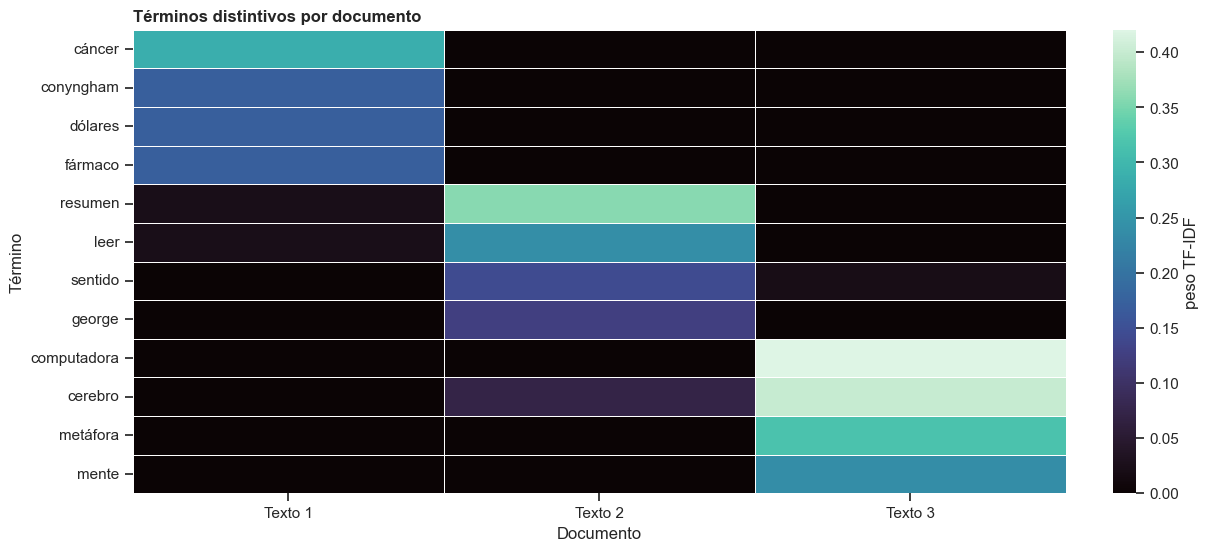

In [14]:
# Seleccionamos los top-4 términos TF-IDF de cada documento (sin repetir)
terminos_heatmap = list(dict.fromkeys(
    top_tfidf.groupby("unidad").head(4)["término"].tolist()
))
matriz_heatmap = tfidf_df[terminos_heatmap].T

fig, ax = plt.subplots(
    figsize=(12, max(4, len(terminos_heatmap) * 0.45)),
    constrained_layout=True,
)
sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)
ax.set_title("Términos distintivos por documento", loc="left", fontweight="bold")
ax.set_xlabel("Documento")
ax.set_ylabel("Término")
plt.show()

---

## 6. Del patrón al fragmento

Acá reaparece la lectura cercana. Una vez detectado un término distintivo, volvemos al documento para ver cómo aparece, con qué tono y en qué marco argumentativo.

Tomamos el término TF-IDF más distintivo de cada documento y buscamos un fragmento del texto original donde aparece.

In [15]:
# Tomamos el término más distintivo (#1) de cada documento
terminos_retorno = top_tfidf.groupby("unidad").head(1).reset_index(drop=True)
display(terminos_retorno)

,unidad,rango,término,tfidf
0,Texto 1,1,cáncer,0.2867
1,Texto 2,1,resumen,0.3589
2,Texto 3,1,computadora,0.4204


In [16]:
def extraer_fragmento(texto, termino, ventana=140):
    """Busca un término en el texto original y devuelve un fragmento
    centrado en la primera aparición, con contexto alrededor."""
    patron = re.compile(rf"\b{re.escape(termino)}\b", flags=re.IGNORECASE)
    coincidencia = patron.search(texto)
    if not coincidencia:
        return "No se encontró el término en el texto original."

    # Recortamos una ventana alrededor de la primera aparición
    inicio = max(0, coincidencia.start() - ventana)
    fin = min(len(texto), coincidencia.end() + ventana)
    fragmento = texto[inicio:fin].strip()

    # Agregamos "..." si el fragmento no empieza/termina con el texto completo
    if inicio > 0:
        fragmento = "..." + fragmento
    if fin < len(texto):
        fragmento = fragmento + "..."
    return fragmento


# Buscamos el fragmento para cada término distintivo
fragmentos = []
for fila in terminos_retorno.itertuples(index=False):
    texto_original = df.loc[df["titulo_corto"] == fila.unidad, "texto"].iloc[0]
    fragmentos.append({
        "documento": fila.unidad,
        "término": fila.término,
        "fragmento": extraer_fragmento(texto_original, fila.término, ventana=VENTANA_FRAGMENTO),
    })

df_fragmentos = pd.DataFrame(fragmentos)
display(df_fragmentos)

,documento,término,fragmento
0,Texto 1,cáncer,"...ales usamos ChatGPT para escribir un correo o resumir lo que nos da fiaca leer, un emprendedor tecnológico australiano lo usó para cu..."
1,Texto 2,resumen,...cula que “ahorre” el esfuerzo de leer el libro no queda alternativa más que enfrentarlo o bien buscar si algún alma caritativa dejó u...
2,Texto 3,computadora,...no su ingenio— y lo ridículas que nos resultan a la vista de nuestra mejor evidencia actual. Pero cuando se menciona que el cerebro e...


---

## 7. Escritura interpretativa guiada

Usá estas preguntas para convertir resultados en argumento:

1. **Lectura distante**
   - ¿Qué términos o asociaciones aparecen en más de un texto?
   - ¿Qué términos vuelven singular a cada documento?
   - ¿Qué patrón lograste ver recién cuando cambiaste de escala?

2. **Lectura cercana**
   - Cuando volvés al fragmento, ¿el término distintivo sostiene la interpretación inicial o la complica?
   - ¿Aparece como afirmación, crítica, analogía, advertencia o ejemplo?
   - ¿Qué matiz se pierde si te quedás solo con la tabla o el gráfico?

3. **Visualización y comprensión**
   - ¿Qué gráfico ayudó realmente a comparar mejor?
   - ¿Qué información sería más difícil de ver en una lista larga de números?
   - ¿Qué simplificación visual mejoró la legibilidad sin deformar el análisis?

## Cierre
Este flujo no reemplaza el TPI, pero lo prepara bien: corpus pequeño, representaciones sparse, visualizaciones sobrias y vuelta sistemática al texto. En el trabajo integrador vas a reutilizar esta lógica con tu propio corpus y con una pregunta discursiva mejor definida.